# [1교시]

In [ ]:
# 신경망

# 퍼셉트론

# 활성화 함수로 통과한다
# 입력구분이 존재 - 입력(x1, x2, x3 ...)
# 선형회귀처럼 가중치 존재 - 가중치(w1, w2, w3 ...)
# 가중합(w1*x1 + w2*x2 + w3*x3 + ...)
# 활성화 함수(activation function) : 가중합이 임계값(threshold) 이상이면 1, 그렇지 않으면 0. 임계값을 조정하여 퍼셉트론 올바른 출력을 내도록 학습하는 알고리즘
# 퍼셉트론은 선형 분류기(linear classifier)로, 선형적으로 구분 가능한 문제에 대해서만 올바른 출력을 낼 수 있음
# XOR 문제는 선형적으로 구분 불가능한 문제로, 퍼셉트론으로 해결할 수 없음

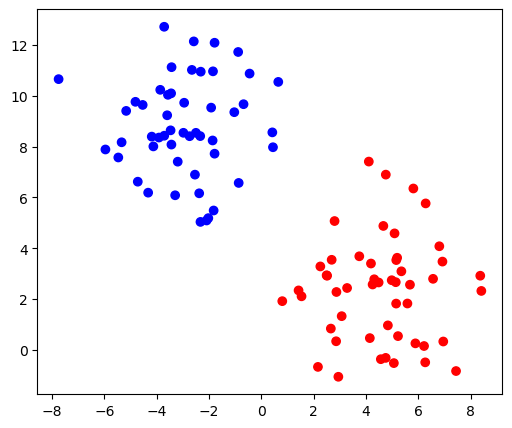

In [1]:
# 데이터 만들기
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=2.0
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.show()

In [2]:
# 직선 두개로 나눈다
# w1*x1 + w2*x2 + b = 0 ==> 직선의 공식
import numpy as np
np.random.seed(100)
w = np.random.randn(2)
b = np.random.randn()
w, b

(array([-1.74976547,  0.3426804 ]), 1.153035802563644)

In [ ]:
# y = f(x) = ax + b
# 수식을 변형하는 방법
# w1*x1 + w2*x2 + b = 0 , y = ?
# W1*x + W2*y + b = 0
# W2*y = -(W1*x + b)
# y = -(W1*x + b) / W2

In [3]:
# 직선을 그리는 함수
def plot_line(w, b):
    x_vals = np.linalg(X[:, 0].min(), X[:,1].max(), 100)
    y_vals = -(w[0]*x_vals + b) / w[1]

# w : 행렬  / 벡터 : 모든애들을 각각 곱하고 더함
def predict(x, w, b):
    value = np.dot(w, x) + b # 연속적인 값(실수)
    # 연속적인 값을 최종적으로, 양성(1), 음성(-1)로 변환해준다
    return np.sign(value) # 양성(1) 음성(-1) => 0 (경계선)

# 값이 0이다, 1이다 라고 정의 하는것을 "활성화 함수"라고 함

In [ ]:
# 예시
# np.dot(곱하고 더한것과 같다 ' sum(a*b = np.dot(a, b)))
# w = np.array( [1, 1.5, 2.5] )
# x = np.array( [10, 20, 30] )
# sum(w*x), np.dot(w, x)

w = [1, 1.5, 2.5]
x = [10, 20, 30]
np.dot(w, x)

# [2교시]

In [ ]:
def find_misclassified(x, y, b):
    for i in range(len(x)):
        xi = x[i]
        yi = 1 if y[i] == 1 else -1
        pred = predict(xi, w, b)
        if pred != yi:
            return xi, yi
    return None, None

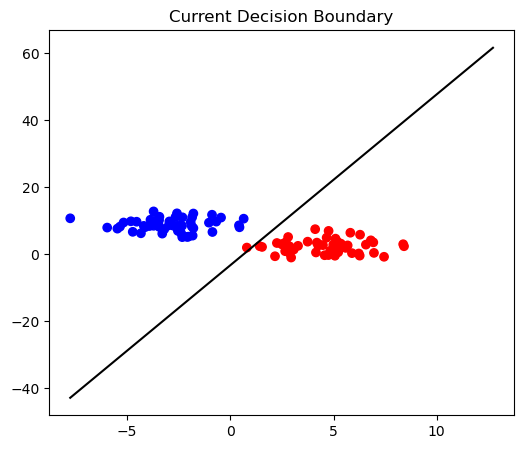

In [4]:
# 직선을 그리는 함수
def plot_line(w, b):
    x_vals = np.linspace(X[:, 0].min(), X[:, 1].max(), 100)
    y_vals = -(w[0]*x_vals +b) / w[1]
    fig, ax = plt.subplots(figsize = (6,5))
    ax.scatter(X[:,0], X[:, 1], c=y, cmap='bwr')
    ax.plot(x_vals, y_vals, color='black')
    ax.set_title('Current Decision Boundary')
    plt.show()

plot_line(w, b)

In [ ]:
def update(w, b, x, y, lr=0.1):
    w = w + lr * y * x
    b = b + lr * y
    return w, b

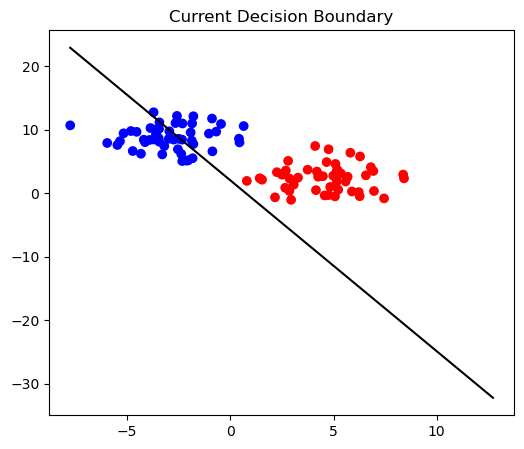

In [5]:
# 틀린점 하나 발견
def perceptron_step(X,y,w,b,lr=0.1):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]
        yi = 1 if yi == 1 else -1
        pred = np.sign(np.dot(w,xi) +b )
        if pred != yi:
            w = w + lr * yi * xi
            b = b + lr*yi
            return w, b
    return w,b 
# 한번 업데이트
w,b = perceptron_step(X,y,w,b)
plot_line(w,b)

In [6]:
# 반복
for i in range(100):
    w, b = perceptron_step(X, y, w, b)

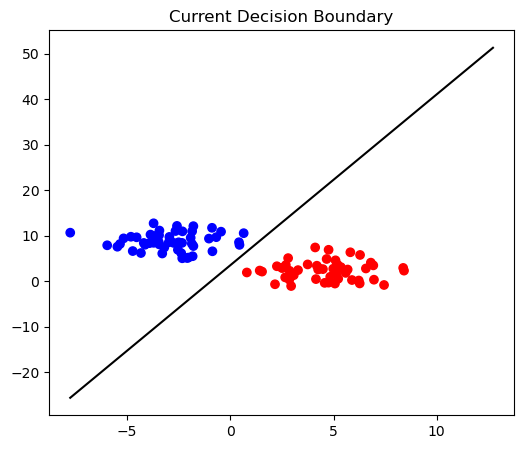

In [7]:
plot_line(w, b)

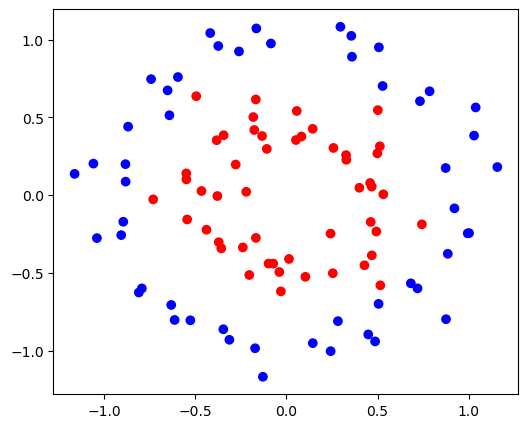

In [8]:
# 실패사례
from sklearn.datasets import make_circles
X2, y2 = make_circles(
    n_samples=100,
    noise = 0.1,
    factor = 0.5, 
    random_state = 42
)
_, ax = plt.subplots(figsize=(6,5))
ax.scatter(X2[:,0], X2[:, 1], c=y2, cmap='bwr')
plt.show()

In [ ]:
# perceptron은 직선이 안되지만, 다층 퍼셉트론은 가능하다.

# 다층 퍼셉트론 : 직선 여러개 생성이 가능하다.
# 입력층 -> 은닉층 -> 출력층
# 은닉층 뉴런 하나 = 직선 하나

# 은닉층 = 퍼셉트론 하나 (=z)
# z = w1*x1 + w2*x2 + b
# a = activation(z)

In [9]:
# 퍼셉트론 라이브러리
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X.to_numpy(), y)

X_new = (X.iloc[:10].to_numpy()).reshape(-1, 4)
print(X_new)
per_clf.predict(X_new), y[-10:]

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]),
 140    False
 141    False
 142    False
 143    False
 144    False
 145    False
 146    False
 147    False
 148    False
 149    False
 Name: target, dtype: bool)

# [3교시]

| 문자 | 소문자 LaTeX | 대문자 LaTeX | 표시 |
|------|--------------|--------------|------|
| 알파 | `\alpha` | A (일반 A) | \( \alpha, A \) |
| 베타 | `\beta` | B (일반 B) | \( \beta, B \) |
| 감마 | `\gamma` | `\Gamma` | \( \gamma, \Gamma \) |
| 델타 | `\delta` | `\Delta` | \( \delta, \Delta \) |
| 엡실론 | `\epsilon` 또는 `\varepsilon` | E (일반 E) | \( \epsilon, \varepsilon, E \) |
| 제타 | `\zeta` | Z (일반 Z) | \( \zeta, Z \) |
| 에타 | `\eta` | H (일반 H) | \( \eta, H \) |
| 세타 | `\theta` 또는 `\vartheta` | `\Theta` | \( \theta, \vartheta, \Theta \) |
| 이오타 | `\iota` | I (일반 I) | \( \iota, I \) |
| 카파 | `\kappa` | K (일반 K) | \( \kappa, K \) |
| 람다 | `\lambda` | `\Lambda` | \( \lambda, \Lambda \) |
| 뮤 | `\mu` | M (일반 M) | \( \mu, M \) |
| 뉴 | `\nu` | N (일반 N) | \( \nu, N \) |
| 크사이 | `\xi` | `\Xi` | \( \xi, \Xi \) |
| 오미크론 | o (일반 o) | O (일반 O) | \( o, O \) |
| 파이 | `\pi` | `\Pi` | \( \pi, \Pi \) |
| 로 | `\rho` 또는 `\varrho` | P (일반 P) | \( \rho, \varrho, P \) |
| 시그마 | `\sigma` | `\Sigma` | \( \sigma, \Sigma \) |
| 타우 | `\tau` | T (일반 T) | \( \tau, T \) |
| 업실론 | `\upsilon` | `\Upsilon` | \( \upsilon, \Upsilon \) |
| 파이(φ) | `\phi` 또는 `\varphi` | `\Phi` | \( \phi, \varphi, \Phi \) |
| 카이 | `\chi` | X (일반 X) | \( \chi, X \) |
| 프사이 | `\psi` | `\Psi` | \( \psi, \Psi \) |
| 오메가 | `\omega` | `\Omega` | \( \omega, \Omega \) |


# 다층 퍼셉트론(MLP) 학습의 핵심 알고리즘과 수식
- 예측값과 정답의 차이를 줄이도록 w와 b를 조금씩 바꾸는 과정
- 즉, 한 번에 정답을 맞히는 것이 아니라 틀린 방향을 보고 다음 예측을 더 좋게 만드는 반복 과정

## 1. MLP 학습의 기본 흐름
- 순전파(Forward) : 입력 x가 층을 지나 예측값 $ \hat{y} $ 를 만든다
- 손실 계산(Loss) : 실제값 y와 예측값 $ \hat{y} $ 의 차이를 수치화
- 역전파(Backpropagation) : 손실이 줄어드는 방향으로 각 파라미터의 영향도를 계산
- 업데이트(Update) : 계산된 방향으로 w와 b를 조금 조정

## 2. 대표 손실 함수
- 분류에서 자주 쓰는 손실:
    - 이진 분류: Binary Cross-Entropy
    - 다중 분류: Cross-Entropy
- 회귀에서 자주 쓰는 손실:
    - MSE = (1/m) * Σ(y - ŷ)^2
- 직관:
    - 손실이 클수록 모델이 많이 틀렸다는 뜻
    - 학습은 손실을 줄이는 방향으로 진행

## 3. 역전파의 핵심 아이디어
- 체인 룰(chain rule)을 이용해 "각 층이 손실에 얼마나 기여했는가"를 뒤에서 앞으로 계산
- 대표적인 표현:
    - $ \alpha $ L / $ \alpha $ w
    - $ \alpha $ L / $ \alpha $ b
- 의미:
    - L : 손실
    - w, b : 학습 할 파라미터
- 직관:
    - 최종 오차를 처음 층까지 거슬러 올라가며 책임을 나눠 갖는 방식

## 4. 다층 퍼셉트론 학습전략
- 가중치 초기화 : 너무 크거나 작지 않게 시작
- 활성화 함수 선택 : ReLU/sigmoid/tanh
- 학습률(learning rate) : 너무 크면 발산, 너무 작으면 느림
- 배치 크기(batch size) : 한 번에 몇 개 샘플을 보고 업데이트 할지 결정
- 에폭(epoch) : 전체 데이터를 몇 번 반복해서 볼지 결정
- 정규화(regularization) : 과적합을 줄이기 위한 장치

### 보조 수식
- 선형층 : z = Wx + b
- 활성화 : h = φ(z) 
- 손실 : L(y, $ \hat{y} $)
- 파라미터 업데이트 : w := w - 𝜂 * 𝛼L/𝛼w
- 변수 의미
- 𝜂 : 학습률
- $ \alpha $ L / $ \alpha $ w : 손실을 줄이기 위한 기울기

## A) 순전파와 손실: 왜 틀렸는지를 먼저 본다
- 상황:
    - 입력 x가 들어오면 MLP가 ŷ를 예측
    - 실제값 y=1, 예측값 ŷ=0.7이라고 가정
- 계산:
    - 오차 = y - ŷ = 1 - 0.7 = 0.3
    - MSE 한 샘플 기준 제곱 오차 = 0.3^2 = 0.09
- 해석:
    - 틀린 정도를 수치로 바꾸면, 그 다음에 얼마나 고쳐야 할지 판단

## B) 역전파 : 뒤에서 앞으로 책임을 나눈다
- 상황:
    - 2층 신경망이 있다고 가정
    - 마지막 출력층에서 오차 발생

- 직관:
    - 오차는 출력층만의 문제가 아니라 앞선 층의 계산이 누적된 결과
    - 손실의 책임을 체인 룰로 앞층까지 전달

- 해석:
    - 역전파는 "누가 얼마나 틀렸는지"를 미분으로 분배하는 작업

## C) 학습률 : 너무 크면 튀고, 너무 작으면 느리다
- 상황:
    - 현재 w-2, 기울기 = 0.5, 학습률 𝜂=0.1

- 계산:
    - w = 2 - 0.1 * 0.5 = 1.95

- 다른 경우:
    - 𝜂 = 1.0일 때 w = 2 - 1.0 * 0.5 = 1.5

- 해석:
    - 학습률이 너무 크면 한 번에 너무 많이 움직여 오히려 불안정함
    - 학습률이 너무 작으면 개선이 아주 느림

# [4교시]

## D) 배치 크기와 에폭
- 상황:
    - 데이터 100개를 학습한다고 가정

- 미니배치 예시:
    - batch size = 10일 때, 10개씩 잘라 10번 업데이트

- 에폭 예시:
    - epoch = 3일 때 , 전체 100개 데이터를 3번 반복

- 해석:
    - 배치는 한 번에 보는 양, 에폭은 전체를 몇 번 도는지?

## E) 활성화 함수가 왜 필요한가
- 상황:
    - 층마다 단순 선형 계산만 반복하면 전체가 결국 하나의 선형식이 된다.

- 직관:
    - 비선형 활성화가 있어야 층을 깊게 쌓는 의미가 생긴다.

- 해석:
    - ReLU는 음수를 0으로 눌러 패턴을 단순화
    - sigmoid는 0~1 사이로 눌러 확률 해석에 도움을 준다.

## F) BCE(Binary Cross-Entropy)를 손으로 계산해 보기
- 상황:
    - 이진 분류에서 실제값 y=1, 예측확률 ŷ=0.8
- 계산:
    - BCE = -( y*log(ŷ) + (1-y)*log(1-ŷ) )
    - BCE = -( 1log(0.8) + 0log(0.2) ) = -log(0.8) ≈ 0.223
- 비교:
    - 같은 y=1인데 ŷ=0.2라면 BCE = -log(0.2) ≈ 1.609
- 해석:
    - 정답 클래스 확률을 낮게 주면 손실이 크게 증가한다.
    - 그래서 분류에서는 BCE가 "확률 예측의 질"을 더 직접적으로 벌점화한다.

## G) 왜 grad_out = ŷ - y 인가 (코드 연결)
- 상황:
    - 출력층 logit을 z, 확률을 ŷ = sigmoid(z), 손실을 BCE라고 둔다.
- 핵심 결과:
    - dL/dz = ŷ - y
- 해석:
    - 출력층에서 오차 신호는 "예측확률 - 실제값"으로 단순화한다.
    - 그래서 통합 실습 코드의 grad_out = y_hat - y가 바로 이 식이다.

한눈에 비교)
| 개념     | 의미                  | 실무에서 보는 포인트          |
|----------|-----------------------|-------------------------------|
| 순전파   | 입력으로 예측 생성    | 현재 모델 성능 확인           |
| 손실     | 틀린 정도 측정        | 학습 목표 함수                |
| 역전파   | 기울기 계산           | 어떤 파라미터를 얼마나 바꿀지 결정 |
| 학습률   | 한 번에 움직이는 폭   | 안정성/속도 균형              |
| 배치 크기| 한 번에 보는 샘플 수  | 메모리/노이즈/속도 균형       |
| 에폭     | 전체 반복 횟수        | 충분히 학습했는지 판단        |


In [10]:
# 순전파 (pred로 예측하는 것)
x = 2.0
w = 3.0
b = -1.0

def forward(x, w, b):
    return w * x + b
pred = forward(w, x, b)

# 오차 구하기
y_true = [1.0, 0.0]
y_pred = [0.7, 0.2]
loss_items = []

# MSE
for yt, yp in zip(y_true, y_pred):
    # SE 오차의 제곱
    loss_items.append ((yt-yp)**2)

mse = sum(loss_items) / len(loss_items)
print('pred', pred)
print('mse', mse)

pred 5.0
mse 0.06500000000000002


In [11]:
# 학습률과 업데이트 w = 가중치, gradient = 기울기, learning_late = 비율
w = 2.0
gradient = 0.5
learning_late = 0.1

def update_weight(w, gradient, learning_late):
    '''w := w - 𝜂 * αL/αw'''
    return w-learning_late*gradient

new_w = update_weight(w, gradient, learning_late)
new_w

1.95

In [12]:
# batch and epoch
data = list(range(1, 11))
batch_size = 4
epochs = 2

batches = []
for start in range(0, len(data), batch_size):
    batches.append(data[start:start+batch_size])

for epoch in range(epochs):
    for data in batches:
        
        # forward
        # loss
        # gradient
        # backward
        # update

_IncompleteInputError: incomplete input (3190865348.py, line 17)

생물학적 뉴런에서 인공뉴런까지 (3), (4)
퍼셉트론, 계단함수
퍼셉트론(perceptron) : 가장 간단한 인공 신경망 구조로, 1957년에 프랑크 로젠블라트가 제안, 헤비사이드 계단 함수
퍼셉트론 : 하나의 층 안에 놓으니 하나 이상의 TLU로 구성, 각각의 TLU는 모든 입력에 연결

# [5교시]

- z = w x + b 
- step(w^Tx + b) ==> 출력값을 0과 1로 분류해주는 함수로 통과해야함, 출력함수는 보통 계단 함수를 사용
- 계단함수 : x값을 다 정리해서 0보다 크면 1에 적재

## 일반 퍼셉트론 이해하기
- 수학공식:
    - z= w^Tx + b
    - y_hat = 1 if z >= 0 else 0
    - w := w + 𝜂 * (y-y_hat)*x
    - b := b + 𝜂 * (y-y_hat)

- 공식 풀이:
    - z는 입력 x를 가중합한 "판단 점수"
    - y_hat은 임계값(0) 기준으로 0/1을 결정한 최종 예측
    - (y-y_hat)는 예측 오차이며, 오차가 0이면 업데이트가 없음
    - 오차가 있으면 오차 방향으로 w,b를 조정해 다음 예측을 개선

- 샘플 적용(AND 데이터 한 점):
    - 초기값 : w=[0,0], b=-0.3, 𝜂=0.2
    - 샘플 : x=[1, 1], y=1
    - 계산 : z=0*1 + 0*1 - 0.3 = -0.3 => y_hat=0
    - 오차 : y - y_hat = 1 - 0 = 1
    - 업데이트 :
        - w'= [0,0] + 0.21[1,1] = [0.2, 0.2]
        - b'= -0.3 + 0.2*



다층 퍼셉트론(MLP)
- 퍼셉트론을 여러 개 쌓아올리면 일부 제약을 줄일 수 있음
- 다층 퍼셉트론의 XOR 문제 풀기

In [ ]:
# 퍼셉트론
# AND gate 데이터
dataset = [
    ([0.0, 0.0], 0.0),
    ([0.0, 1.0], 0.0),
    ([1.0, 0.0], 0.0),
    ([1.0, 1.0], 1.0)]
w = [0.0, 0.0]
b = -0.3
learning_rate = 0.2

# 활성화 함수
def step(z):
    return 1 if z >= 0 else  0

# forward
def predict(x, w, b):
    # z = w[0]*x[0] + w[1]*x[1] + b
    z = np.dot(w, x) + b
    return step(z), z

import numpy as np

for x, y in dataset:
    y_hat, z = predict(x, w, b)
    error = y - y_hat
    # 퍼셉트론 업데이트 wi = wi + 학습률*오류*xi
    # w + learning_rate*error*x
    print(w, learning_rate, error, x)


# (6교시)

핵심 수식
- 가중합 : z = d

주요 활성화 함수
- 계단 함수 : 0 또는 1
- 시그모이드 : 1 / (1+e-z)
- ReLU : max(0, z)

## 학습 - 오차를 줄이는 방향

wi <- wi + n * (y-y^)*xi

In [ ]:
0.8+0.5*(1-0)*1

In [ ]:
# 정답 : 1, 예측 : 0, 오차 : +1
# w_new = w_old + lr*(y-y_hat)*x
0.3 + 0.5 * (1-0) * 1 # ==> 0.8
# 가중치, 비율, 오차
# w_old = 0.3, w_new = 0.8
# delta_w(역삼각형 w) = 0.5


# 정답 : 0, 예측 : 1 (예측값이 정답값보다 높을 때 과대, 오차 : -1)
0.3 + 0.5 *(0-1)*1 # ==> -0.2
# w_old 0.3
# w의 변화량 -0.5 (0.5만큼 감소)
# 
# 정답 : 1, 예측 : 1
# 0.3 + 0.5 * (1-1)*1 # ==> 0.3
# w_old : 0.3
# w의 변화량 0 

In [ ]:
import numpy as np
# xor 데이터
x = np.array([[0,0], [1,1], [0,1], [1,0]])
y = np.array([0, 0, 1, 1])

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x, y)
model.predict(x)

In [13]:
# 퍼셉트론을 못한다, 가중치 편향
import numpy as np
w = np.array([0.0, 0.0])
b = 0.0
lr = 0.1

# 학습 루프 100
for epoch in range(10):
    for xi, yi in zip(x, y):
        z = np.dot(w, xi) + b
        y_hat = 1 if z >= 0 else 0
        error = yi - y_hat
        w += lr * error *xi
        b += lr*error

# print(f'학습후 w : {w} b : {b}')
new_x = np.array([[0,0], [1,1], [0,1], [1,0]])
for n_x in new_x :
    z = np.dot(w, n_x) + b
    y_hat = 1 if z >=0 else 0
    print(f'{n_x}에 대한 y의 값 예측 {y_hat}')

TypeError: 'float' object is not iterable

In [ ]:
# 퍼셉트론을 못한다, 가중치 편향

x = np.array([[0,0], [1,1], [0,1], [1,0]])
y = np.array([0,1,1,0])

import numpy as np
np.random.seed(42)
w = np.random.randn(2)
b = np.random.rand()
lr = 0.1

# 학습 루프 100
for epoch in range(10):
    for xi, yi in zip(x, y):
        z = np.dot(w, xi) + b
        y_hat = 1 if z >= 0 else 0
        error = yi - y_hat
        w += lr * error *xi
        b += lr*error

# print(f'학습후 w : {w} b : {b}')
new_x = np.array([[0,0], [1,1], [0,1], [1,0]])
for n_x, y_ in zip(new_x, y) :
    z = np.dot(w, n_x) + b
    y_hat = 1 if z >=0 else 0
    print(f'{n_x}에 대한 y의 값 예측 {y_hat} 정답 : {y_}')

# [7교시]

In [ ]:
# perceptron(SLP)
# multi perceptron(MLP)

# 은닉층 1개 = 직선 2개 만든다는의미, 뉴런이 2개
# 입력 -> 은닉층(2개) -> 출력
# z1 = w11*x1 + w12*x2 ... +b1
# z2 = w21*x1 + w22*x2 ... +b2

In [ ]:
import numpy as np
np.random.seed(42)
# xor 
X = np.array([
    (0,0), (1,1), (1,0), (0,1)
])
y = np.array([0,0,1,1])

# 활성화함수로 계단함수
def step(z):
    return np.where(z)
# 최초 가중치
w1 = np.random.randn(2)
w2 = np.random.randn(2)
b1, b2 = np.random.randn(2)

print(f'최초 가중치 : {w1, b1}')
print(f'최초 가중치 : {w2, b2}')

print(X.shape, w1.shape)

np.dot(X, w1)

In [ ]:
import numpy as np
np.random.seed(42)
# xor
X = np.array([
    (0,0),(1,1),(1,0),(0,1)
])
y = np.array([0,0,1,1])

# 활성화함수로 계단함수
def step(z):
    return np.where(z>=0, 1 ,0)

# 최초가중치
w1= np.random.randn(2)
w2= np.random.randn(2)
b1,b2 = np.random.randn(2)
print(f'최초 가중치 : {w1,  b1}')
print(f'최초 가중치 : {w2,  b2}')

print(X.shape, w1.shape)

np.dot(X, w1)

# 은닉층
z1 = np.dot(X,w1) + b1
z2 = np.dot(X,w2) + b2


print(f'은닉층 선형결합')
print(f'z1 : {z1}')
print(f'z2 : {z2}')

# 활성화 함수
h1 = step(z1)
h2 = step(z2)

print(f'은닉층 출력')
print(f'h1 : {h1}')
print(f'h2 : {h2}')

# 출력층
v = np.random.randn(2)
b_out = np.random.randn()
print(f'출력층 가중치 : v: {v} b_out : {b_out}')

# 은닉층 묶기
H = np.column_stack((h1, h2))
# y_hat = v1*h1 + v2*h2 + b
z_out = np.dot(H, v) + b_out

print(f'출력층 선형결합')
print(f'z_out : {z_out}')

# 최종 출력
y_pred = step(z_out)
print(f'최종출력 : {y_pred}')

# [8교시]

## 퍼셉트론의 업데이트의 핵심
- error = y - y_hat
- w += lr\*error\*xi
- b += lr*error
- 오차 => 바로 가중치 수정 why 층이 하나고 이 층의 출력이 바로 결과

## MLP
- 입력 -> 은닉층(h1, h2) -> 출력
- 출력 오차 -> 출력층 수정 -> 은닉층도 수정

- z1 = w1 x X + b1
- h1 = step(z1)
- z2 = w2 x X + b2
- h2 = step(z2)
- z = v1xh1 + v2xh2 + b

## backward
### 출력층 업데이트
- v += lr x error x h

### 은닉층 업데이트
- w += lr x error x X

In [ ]:
import numpy as np

np.random.seed(42)

# XOR 데이터
X = np.array([
    [0,0],
    [1,1],
    [0,1],
    [1,0]
])

y = np.array([[0],[0],[1],[1]])

lr = 0.1

# =========================
# sigmoid 함수
# =========================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)



# =========================
# 가중치 초기화
# =========================

# 입력 → 은닉층
W1 = np.random.randn(2,2)
b1 = np.random.randn(1,2)

# 은닉층 → 출력층
W2 = np.random.randn(2,1)
b2 = np.random.randn(1,1)

# =========================
# 학습 루프
# =========================

for epoch in range(5000):

    for xi, yi in zip(X,y):

        xi = xi.reshape(1,2)
        yi = yi.reshape(1,1)

        # =================
        # Forward
        # =================

        z1 = np.dot(xi, W1) + b1
        h = sigmoid(z1)

        z2 = np.dot(h, W2) + b2
        y_hat = sigmoid(z2)

        # =================
        # Error
        # =================

        error = yi - y_hat

        # =================
        # Backprop
        # =================

        d_output = error * sigmoid_derivative(y_hat)

        d_hidden = (
            d_output.dot(W2.T)
            * sigmoid_derivative(h)
        )

        # =================
        # 가중치 업데이트
        # =================

        W2 += lr * h.T.dot(d_output)
        b2 += lr * d_output

        W1 += lr * xi.T.dot(d_hidden)
        b1 += lr * d_hidden

# =========================
# 테스트
# =========================

print("\n학습 후 결과")

for xi, yi in zip(X,y):

    xi = xi.reshape(1,2)

    h = sigmoid(np.dot(xi,W1)+b1)
    y_hat = sigmoid(np.dot(h,W2)+b2)

    pred = 1 if y_hat >= 0.5 else 0

    print(
        xi.flatten(),
        "예측:", pred,
        "실제:", yi[0]
    )